In [1]:
import sys, os
import requests
import numpy as np
import pandas as pd
import xarray as xr

import cartopy
import matplotlib as mpl
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../spectral-spatial-sst-model"))
from explanatory_variables import reconstruct_predictors, predictor_in_pixel

In [2]:
dataset_path = "E:/dataset"
gam_predictors = xr.open_dataset(f"{dataset_path}/mx_secihti_cicese_eval_sst_gam_predictors_nep_0p10deg_200501-202508_v1.nc")
gam_predictors = gam_predictors.sel(lat=slice(20, 35), lon=slice(-125, -105))
gam_predictors

predictors_spectral_modes_files = {
	"adt": "mx_secihti_cicese_spectral_modes_adt_nep_0p083deg_v1.nc",
	"t2m": "mx_secihti_cicese_spectral_modes_t2m_nep_0p25deg_v1.nc",
	"u10": "mx_secihti_cicese_spectral_modes_u10_nep_0p25deg_v1.nc",
	"v10": "mx_secihti_cicese_spectral_modes_v10_nep_0p25deg_v1.nc",
	"pdo": "mx_secihti_cicese_spectral_modes_pdo_v1.nc",
	"noi": "mx_secihti_cicese_spectral_modes_noi_v1.nc",
	"np": "mx_secihti_cicese_spectral_modes_np_v1.nc",
	"oni": "mx_secihti_cicese_spectral_modes_oni_v1.nc",
}

predictors_modes = {
	name: xr.open_dataset(f"{dataset_path}/{file}") 
		for name, file in predictors_spectral_modes_files.items()
}

gam_predictors

c:\Users\USER\anaconda3\lib\site-packages\xarray\backends\plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
No module named 'pooch'
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.Dataset> Size: 244kB
Dimensions:  (time: 1, lat: 151, lon: 201)
Coordinates:
  * time     (time) datetime64[ns] 8B 2025-08-01
  * lat      (lat) float32 604B 20.0 20.1 20.2 20.3 20.4 ... 34.7 34.8 34.9 35.0
  * lon      (lon) float32 804B -125.0 -124.9 -124.8 ... -105.2 -105.1 -105.0
Data variables:
    pdo      (time, lat, lon) int8 30kB ...
    noi      (time, lat, lon) int8 30kB ...
    oni      (time, lat, lon) int8 30kB ...
    np       (time, lat, lon) int8 30kB ...
    t2m      (time, lat, lon) int8 30kB ...
    adt      (time, lat, lon) int8 30kB ...
    u10      (time, lat, lon) int8 30kB ...
    v10      (time, lat, lon) int8 30kB ...
Attributes:
    title:               Predictor selection maps for GAM-based SST models
    summary:             Binary maps indicating the selection of climate indi...
    institution:         SECIHTI / CICESE-UALP
    source:              GAM-based statistical modeling of SST
    history:             Created on 2026-01-03T14:46:55.032876
    references:          
    Conventions:         CF-1.8
    spatial_resolution:  0.10 degree
    lat_min:             20
    lat_max:             55
    lon_min:             -140
    lon_max:             -105

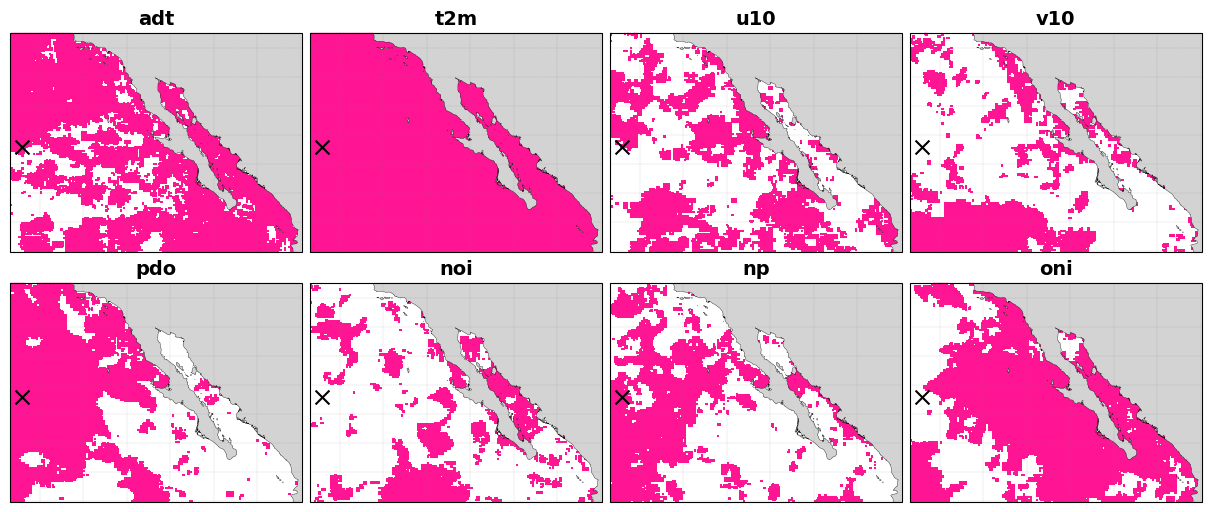

In [3]:
point = [-124.25,27.1666666667]
fig = plt.figure(figsize=(12, 5), constrained_layout=True)

bounds = [0, 0.5, 1]
cmap = mpl.colors.ListedColormap(["none", "deeppink"])
norm = mpl.colors.BoundaryNorm(bounds, cmap.N)

for k, key in enumerate(predictors_modes.keys()):
    ax = fig.add_subplot(2, 4, k+1, projection=cartopy.crs.PlateCarree())
    land = cartopy.feature.NaturalEarthFeature('physical', 'land', scale="10m", edgecolor='k', facecolor=cartopy.feature.COLORS['land'])
    ax.add_feature(land, facecolor='lightgray', linewidth=0.25)
    gl = ax.gridlines(crs=cartopy.crs.PlateCarree(), draw_labels=False, linewidth=0.25, color='gray', alpha=0.5, linestyle='--')

    ax.pcolor(gam_predictors.lon, gam_predictors.lat, np.nan_to_num(gam_predictors[key].data[0,:,:], nan=0), cmap=cmap, norm=norm)
    ax.scatter(point[0], point[1], marker="x", s=100, c="black")
    ax.set_title(key, fontweight="bold", fontsize=14)

plt.show()

In [4]:
sst_ds = xr.open_dataset(f"{dataset_path}/mursst.nc")
sst_ds = sst_ds.sel(latitude=slice(20, 35), longitude=slice(-125, -105))

X_ds = reconstruct_predictors(
	gam_predictors, 
	predictors_modes, 
	sst_ds.time.values, 
)
X_ds

<xarray.Dataset> Size: 493MB
Dimensions:           (time: 254, predictor: 8, lat: 151, lon: 201)
Coordinates:
  * time              (time) int32 1kB 0 1 2 3 4 5 6 ... 248 249 250 251 252 253
  * predictor         (predictor) <U3 96B 'pdo' 'noi' 'oni' ... 'u10' 'v10'
  * lat               (lat) float32 604B 20.0 20.1 20.2 20.3 ... 34.8 34.9 35.0
  * lon               (lon) float32 804B -125.0 -124.9 -124.8 ... -105.1 -105.0
Data variables:
    predictor_signal  (time, predictor, lat, lon) float64 493MB -0.5186 ... 0.0

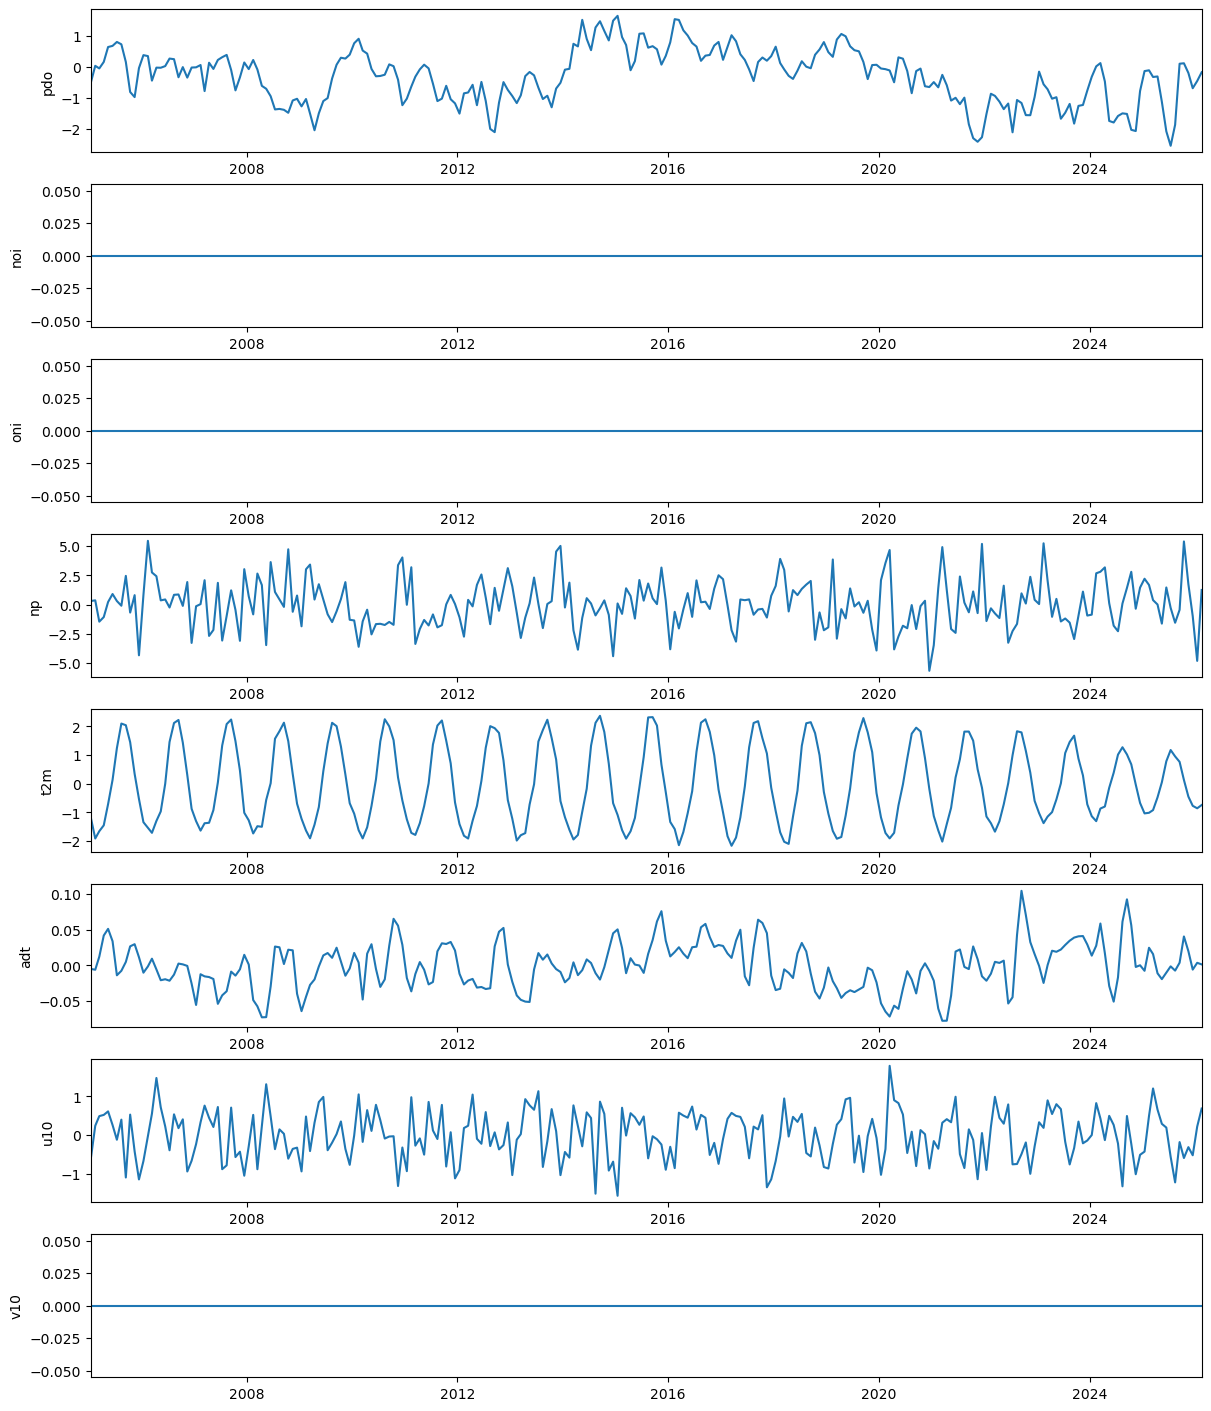

In [5]:
lon_idx = np.abs(X_ds.lon - point[0]).argmin()
lat_idx = np.abs(X_ds.lat - point[1]).argmin()

fig = plt.figure(figsize=(12, 14), constrained_layout=True) 

for k in range(X_ds.predictor.size):
    ax = fig.add_subplot(X_ds.predictor.size, 1, k+1)
    
    serie = X_ds.predictor_signal[:, k, lat_idx, lon_idx];

    ax.plot(sst_ds.time, serie)
    ax.set_xlim(sst_ds.time[0], sst_ds.time[-1])
    ax.set_ylabel(X_ds.predictor[k].data)

plt.show()

In [6]:
indices = {
    "pdo": "https://psl.noaa.gov/data/correlation/pdo.data",
    "oni": "https://psl.noaa.gov/data/correlation/oni.data"
}

dfs = []
for name, url in indices.items():
    text = requests.get(url).text
    lines = text.strip().splitlines()

    rows = []
    for line in lines[1:]:
        parts = line.split()

        if len(parts) < 13:
            break

        year = int(parts[0])
        values = list(map(float, parts[1:13]))

        for month, value in enumerate(values, start=1):
            if value in [-99.90, -9.90]:
                continue

            rows.append({
                "time": pd.Timestamp(year=year, month=month, day=1),
                name: value
            })

    dfs.append(pd.DataFrame(rows))

df = dfs[0]
for d in dfs[1:]:
    df = df.merge(d, on="time", how="outer")

df = df.sort_values("time").reset_index(drop=True)
df

,time,pdo,oni
0,1948-01-01,-0.11,NaN
1,1948-02-01,-0.74,NaN
2,1948-03-01,-0.03,NaN
3,1948-04-01,-1.33,NaN
4,1948-05-01,-0.23,NaN
...,...,...,...
934,2025-11-01,NaN,-0.55
935,2025-12-01,NaN,-0.54
936,2026-01-01,NaN,-0.37
937,2026-02-01,NaN,-0.15


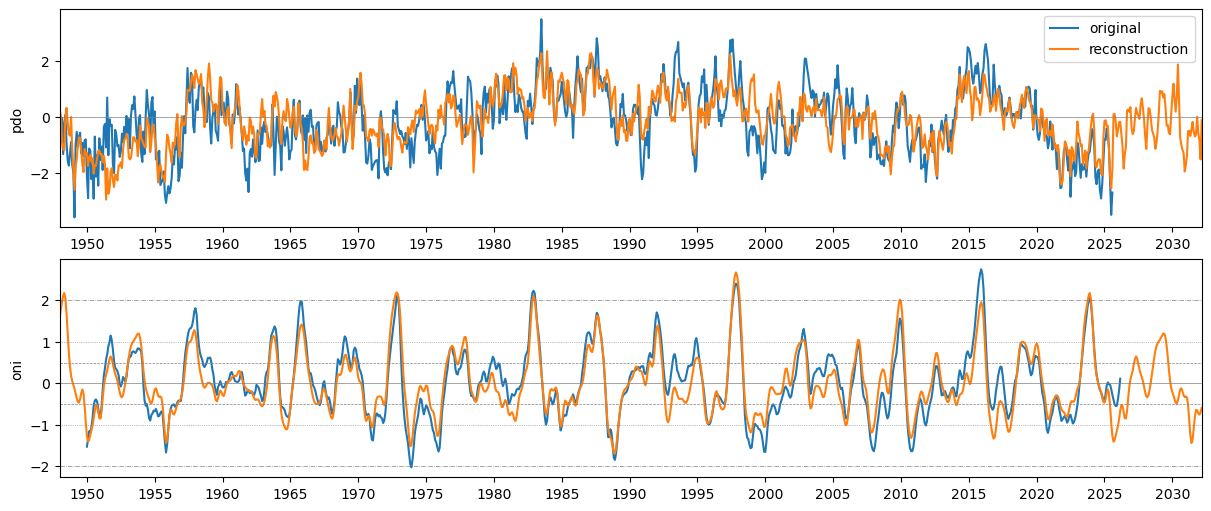

In [7]:
df_ext = df.copy()
horizon = 72

future_time = pd.date_range(start=df_ext.time.iloc[-1] + pd.offsets.MonthBegin(1), periods=horizon, freq="MS")
df_future = pd.DataFrame({"time": future_time})
for col in df_ext.columns:
    if col != "time":
        df_future[col] = np.nan
df_ext = pd.concat([df_ext, df_future], ignore_index=True)

for name, _ in indices.items():
    ds_modes = predictors_modes[name]
    
    t = np.arange(df_ext.time.shape[0])
    ref = ds_modes.attrs["time_reference"].replace("t0 =", "").strip()
    ref = np.datetime64(ref, "M")
    time0 = df_ext.time.values[0].astype("datetime64[M]")
    t0 = (ref - time0).astype(int)

    df_ext[f"{name}_recon"] = predictor_in_pixel([], [], ds_modes, t, t0=t0)

fig = plt.figure(figsize=(12, 5), constrained_layout=True) 

ax = fig.add_subplot(2, 1, 1)
ax.plot(df_ext.time, df_ext.pdo, label="original")
ax.plot(df_ext.time, df_ext.pdo_recon, label=f"reconstruction")
ax.set_xlim(df_ext.time.values[0], df_ext.time.values[-1])
ax.xaxis.set_major_locator(mpl.dates.YearLocator(5))
ax.axhline(y=0, color='grey', lw=0.5)
ax.set_ylabel("pdo")
ax.legend()

ax = fig.add_subplot(2, 1, 2)
ax.plot(df_ext.time, df_ext.oni)
ax.plot(df_ext.time, df_ext.oni_recon)
ax.set_xlim(df_ext.time.values[0], df_ext.time.values[-1])
ax.xaxis.set_major_locator(mpl.dates.YearLocator(5))
for y, ls in zip([-0.5, 0.5, -1, 1, -2, 2], ["--", "--", ":", ":", "-.", "-."]):
    ax.axhline(y=y, ls=ls, color='grey', lw=0.5)
ax.axhline(y=0, color='grey', lw=0.5)
ax.set_ylabel("oni")

plt.show()